In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


In [2]:
# import numpy as np
# import matplotlib.pyplot as plt

# # -----------------------------
# # Parameters
# # -----------------------------
# T = 20.0
# dt = 1e-3
# np.random.seed(0)

# tau_v = 0.050
# tau_s = 0.020
# alpha = 0.08
# b = 3.0
# omega = 2*np.pi*1.0
# x0 = 0.0
# s0 = 0.0

# lambda_max = 2000.0  # Hz safety cap
# sigma_rate = 0.050   # s Gaussian smoothing

# def mu(t):
#     return b + np.cos(omega * t)

# def phi(v):
#     return np.maximum(v, 0.0)**2  # keep rate >= 0

# N = int(np.round(T / dt))
# t = np.arange(N) * dt

# v = np.empty(N)
# s = np.empty(N)
# spk = np.zeros(N, dtype=np.int8)

# v[0] = x0
# s[0] = s0

# for j in range(N - 1):
#     lam = min(phi(v[j]), lambda_max)
#     p = min(lam * dt, 1.0)
#     spk[j] = 1 if np.random.rand() < p else 0

#     s[j + 1] = s[j] + dt * (-s[j] / tau_s) + alpha * spk[j]
#     v[j + 1] = v[j] + dt * (-(v[j]) + mu(t[j]) + s[j]) / tau_v

# # last bin
# lam = min(phi(v[-1]), lambda_max)
# spk[-1] = 1 if np.random.rand() < min(lam * dt, 1.0) else 0

# # Gaussian-smoothed rate
# sigma_bins = sigma_rate / dt
# half_width = int(np.ceil(5 * sigma_bins))
# x = np.arange(-half_width, half_width + 1)
# g = np.exp(-0.5 * (x / sigma_bins) ** 2)
# g /= (g.sum() * dt)  # normalize to produce Hz

# rate_smoothed = np.convolve(spk.astype(float), g, mode="same")

# # Plot
# fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# ax[0].plot(t, v)
# ax[0].set_ylabel("v(t)")

# ax[1].plot(t, rate_smoothed, label=f"Gaussian rate (σ={sigma_rate*1e3:.0f} ms)")
# spike_times = t[spk.astype(bool)]
# ax[1].vlines(spike_times, 0, max(rate_smoothed.max()*0.15, 1.0), linewidth=0.5)
# ax[1].set_xlabel("t (s)")
# ax[1].set_ylabel("rate (Hz)")
# ax[1].legend()

# plt.tight_layout()
# plt.show()

spikes total: 145
v min/max: 0.2 0.6183940289789908
lam min/max: 0.04000000000000001 0.3824111750768689
p min/max: 4.000000000000001e-05 0.0003824111750768689
any NaN in v? False  any NaN in p? False
np.random.rand is: <built-in method rand of numpy.random.mtrand.RandomState object at 0x10c05a640>
np.random.rand() sample: 0.4883631418530673


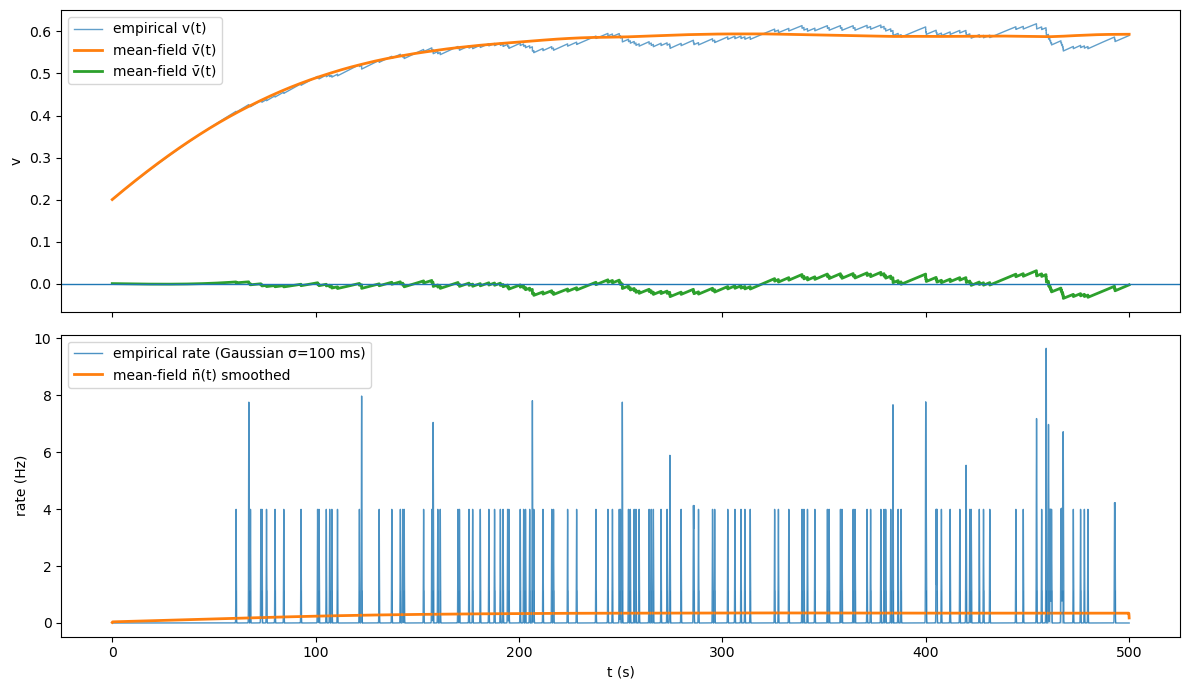

0.5933571978510851
0.5329899427622151


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parameters
# =========================
T = 500.0
dt = 1e-3
np.random.seed(0)

tau   = 200.0
alpha = 4.0
b     = 1.0
a     = 0.0
E     = 0.3
omega = 0.1
x0    = 0.2

lambda_max = 2e10   # Hz cap for numerical stability
sigma_rate = 0.1  # s for Gaussian smoothing

def mu(t):
    return b + a*np.cos(omega * t)

def phi(v):
    return np.maximum(v, 0.0)**2 / (b)   # your choice
    # return np.maximum(v, 0.0)   # your choice

# =========================
# Time grid
# =========================
N = int(np.floor(T / dt))
t = np.arange(N) * dt

# =========================
# Empirical simulation (delta-pulse coupling)
# v_{j+1} = v_j + dt/tau(-v_j + mu) + alpha * spike_j
# =========================
v = np.empty(N)
spk = np.zeros(N, dtype=np.int8)

v[0] = x0

for j in range(N - 1):
    lam = phi(v[j])
    lam = max(0.0, min(lam, lambda_max))
    p = min(lam * dt, 1.0)

    spk[j] = 1 if np.random.rand() < p else 0

    # v[j + 1] = v[j] + (dt * (-v[j] + mu(t[j])) + alpha * spk[j]) / tau
    v[j + 1] = v[j] + (dt * (-v[j] + mu(t[j])) + (E-v[j])*alpha * spk[j]) / tau

# last bin
lam = max(0.0, min(phi(v[-1]), lambda_max))
spk[-1] = 1 if np.random.rand() < min(lam * dt, 1.0) else 0

# empirical rate (raw + Gaussian-smoothed)
rate_raw = spk.astype(float) / dt

sigma_bins = sigma_rate / dt
half_width = int(np.ceil(5 * sigma_bins))
xk = np.arange(-half_width, half_width + 1)
g = np.exp(-0.5 * (xk / sigma_bins) ** 2)
g /= (g.sum() * dt)  # normalize to Hz
rate_emp = np.convolve(spk.astype(float), g, mode="same")

# =========================
# Mean-field (matched discretization)
# E[spike_j | vbar_j] = phi(vbar_j) dt
# =========================
vbar = np.empty(N)
vbar[0] = x0

for j in range(N - 1):
    # vbar[j + 1] = vbar[j] + (dt * (-vbar[j] + mu(t[j])) + alpha * phi(vbar[j]) * dt)/tau
    vbar[j + 1] = vbar[j] + (dt * (-vbar[j] + mu(t[j])) + (E-v[j])*alpha * phi(vbar[j]) * dt)/tau

nbar = phi(vbar)
nbar_smooth = np.convolve(nbar, g, mode="same")

# --- Diagnostics ---
lam_trace = np.maximum(phi(v), 0.0)
lam_cap = np.minimum(lam_trace, lambda_max)
p_trace = np.minimum(lam_cap * dt, 1.0)

print("spikes total:", int(spk.sum()))
print("v min/max:", float(np.min(v)), float(np.max(v)))
print("lam min/max:", float(np.nanmin(lam_cap)), float(np.nanmax(lam_cap)))
print("p min/max:", float(np.nanmin(p_trace)), float(np.nanmax(p_trace)))
print("any NaN in v?", np.isnan(v).any(), " any NaN in p?", np.isnan(p_trace).any())

print("np.random.rand is:", np.random.rand)
print("np.random.rand() sample:", np.random.rand())

# =========================
# Plot overlays
# =========================
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax[0].plot(t, v, linewidth=1.0, alpha=0.7, label="empirical v(t)")
ax[0].plot(t, vbar, linewidth=2.0, label="mean-field v̄(t)")
ax[0].plot(t, v-vbar, linewidth=2.0, label="mean-field v̄(t)")
ax[0].axhline(0, linewidth=1)   # horizontal line at y=0 on the first subplot
ax[0].set_ylabel("v")
ax[0].legend()

ax[1].plot(t, rate_emp, linewidth=1.0, alpha=0.8, label=f"empirical rate (Gaussian σ={sigma_rate*1e3:.0f} ms)")
ax[1].plot(t, nbar_smooth/1000, linewidth=2.0, label="mean-field n̄(t) smoothed")
ax[1].vlines(t[spk.astype(bool)], 0, max(rate_emp.max()*0.12, 1.0), linewidth=0.4, alpha=0.5)

ax[1].set_xlabel("t (s)")
ax[1].set_ylabel("rate (Hz)")
# ax[1].set_ylim([0,20])
ax[1].legend()

plt.tight_layout()
plt.show()

print(vbar[-1])
print(np.mean(v))

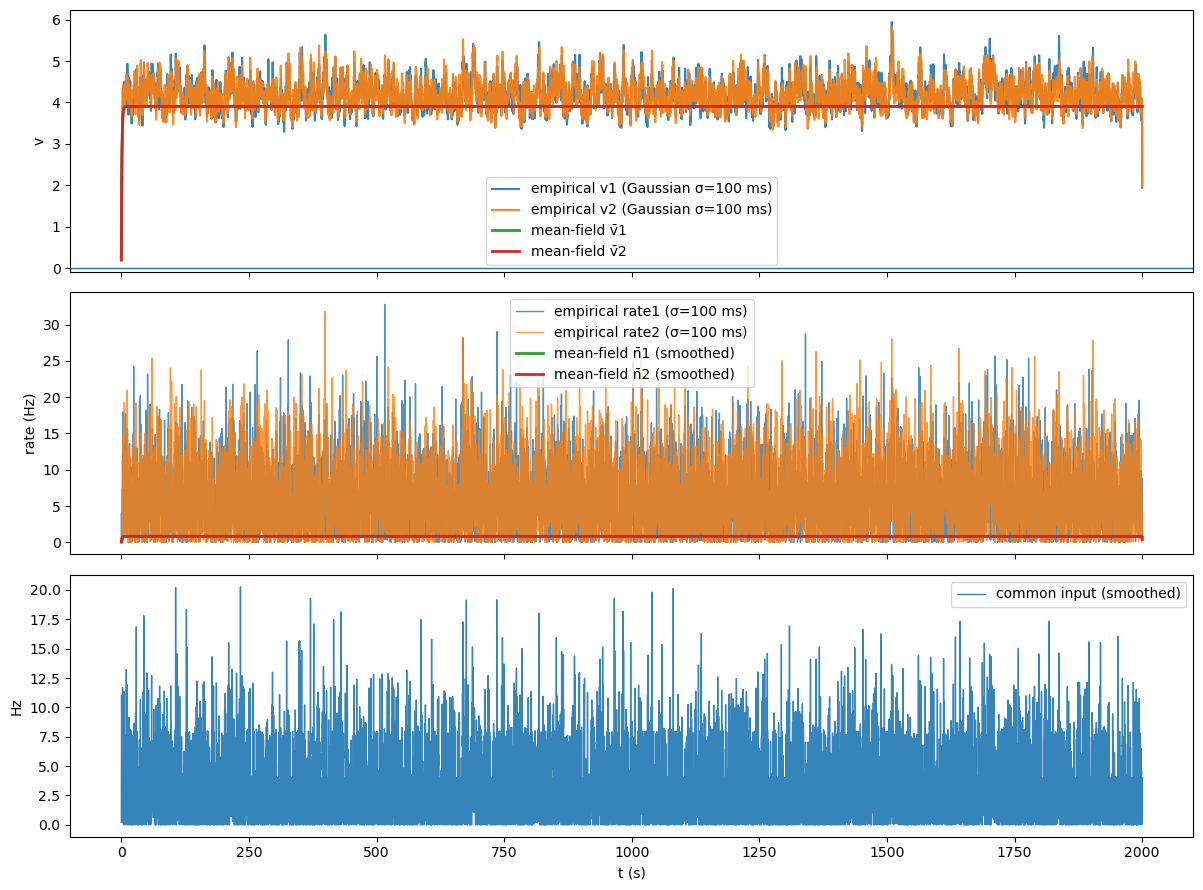

spikes total (1): 11831  spikes total (2): 11904
common events total: 6037
4.197087903268528 4.193369785428635
3.90287277387117 3.90287277387117


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parameters
# =========================
T = 2000.0
dt = 5e-3

tau1, tau2 = 1.0, 1.0

b1, b2 = 3.0, 3.0
a1, a2 = 0.0, 0.0
omega1, omega2 = 0.1, 0.1

alpha11 = 0.0
alpha22 = 0.0
alpha12 = 0.1
alpha21 = 0.1

x01, x02 = 0.2, 0.2

lambda_max = 2e10
sigma_rate = 0.1

# --- common input (Poisson) ---
lamX = 3.0          # Hz of the common Poisson input
alpha1X = 0.2       # pulse size from common input into v1
alpha2X = 0.2       # pulse size from common input into v2

def mu1(t):
    return b1 + a1*np.cos(omega1 * t)

def mu2(t):
    return b2 + a2*np.cos(omega2 * t)

# NOTE: keep b default here; we'll pass b1/b2 explicitly
def phi(v, b=5):
    return np.maximum(v, 0.0)**2 / b

# =========================
# Time grid
# =========================
N = int(np.floor(T / dt))
t = np.arange(N) * dt

# =========================
# Common Poisson input m(t)
# Δm_k ~ Poisson(lamX * dt)
# =========================
m_common = np.random.poisson(lamX * dt, size=N).astype(np.int32)  # counts per bin

# =========================
# Empirical simulation
# =========================
v1 = np.empty(N); v2 = np.empty(N)
spk1 = np.zeros(N, dtype=np.int8); spk2 = np.zeros(N, dtype=np.int8)

v1[0] = x01
v2[0] = x02

for k in range(N - 1):
    lam1 = max(0.0, min(phi(v1[k], b=b1), lambda_max))
    lam2 = max(0.0, min(phi(v2[k], b=b2), lambda_max))
    p1 = min(lam1 * dt, 1.0)
    p2 = min(lam2 * dt, 1.0)

    spk1[k] = 1 if np.random.rand() < p1 else 0
    spk2[k] = 1 if np.random.rand() < p2 else 0

    # network drive
    drive1 = (alpha11 * spk1[k] + alpha12 * spk2[k])
    drive2 = (alpha22 * spk2[k] + alpha21 * spk1[k])

    # common input drive (delta pulses)
    drive1X = alpha1X * m_common[k]
    drive2X = alpha2X * m_common[k]

    v1[k+1] = v1[k] + (dt * (-v1[k] + mu1(t[k])) + drive1 + drive1X) / tau1
    v2[k+1] = v2[k] + (dt * (-v2[k] + mu2(t[k])) + drive2 + drive2X) / tau2

# last-bin spikes (optional)
lam1 = max(0.0, min(phi(v1[-1], b=b1), lambda_max))
lam2 = max(0.0, min(phi(v2[-1], b=b2), lambda_max))
spk1[-1] = 1 if np.random.rand() < min(lam1 * dt, 1.0) else 0
spk2[-1] = 1 if np.random.rand() < min(lam2 * dt, 1.0) else 0

# =========================
# Gaussian-smoothed empirical rates
# =========================
sigma_bins = sigma_rate / dt
half_width = int(np.ceil(5 * sigma_bins))
xk = np.arange(-half_width, half_width + 1)
g = np.exp(-0.5 * (xk / sigma_bins) ** 2)
g /= (g.sum() * dt)  # spikes -> Hz

rate1_emp = np.convolve(spk1.astype(float), g, mode="same")
rate2_emp = np.convolve(spk2.astype(float), g, mode="same")

# =========================
# Mean-field (matched discretization with common Poisson)
# =========================
v1bar = np.empty(N); v2bar = np.empty(N)
n1bar = np.empty(N); n2bar = np.empty(N)

v1bar[0] = x01
v2bar[0] = x02

for k in range(N - 1):
    # honest MF (Euler on continuous-time mean-field ODE)
    v1bar[k+1] = v1bar[k] + (dt/tau1) * (
        -v1bar[k] + mu1(t[k])
        + alpha11 * phi(v1bar[k])
        + alpha12 * phi(v2bar[k])
        + alpha1X * lamX
    )
    
    v2bar[k+1] = v2bar[k] + (dt/tau2) * (
        -v2bar[k] + mu2(t[k])
        + alpha22 * phi(v2bar[k])
        + alpha21 * phi(v1bar[k])
        + alpha2X * lamX
    )

# last point for nbar
lam1b = max(0.0, min(phi(v1bar[-1], b=b1), lambda_max))
lam2b = max(0.0, min(phi(v2bar[-1], b=b2), lambda_max))
n1bar[-1] = min(lam1b * dt, 1.0) / dt
n2bar[-1] = min(lam2b * dt, 1.0) / dt

n1bar_smooth = np.convolve(n1bar, g, mode="same")
n2bar_smooth = np.convolve(n2bar, g, mode="same")

# =========================
# Optional: common input smoothed "rate"
# =========================
rateX_emp = np.convolve(m_common.astype(float), g, mode="same")  # Hz-ish

# --- Gaussian-smoothed empirical voltages (same kernel g, but NO /dt normalization) ---

# Build a Gaussian kernel for smoothing "signals" (voltage), normalized to sum=1
g_v = np.exp(-0.5 * (xk / sigma_bins) ** 2)
g_v /= g_v.sum()

v1_emp_smooth = np.convolve(v1, g_v, mode="same")
v2_emp_smooth = np.convolve(v2, g_v, mode="same")

# =========================
# Plots: overlays + common input
# =========================
fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# voltages
# voltages
# ax[0].plot(t, v1, linewidth=1.0, alpha=0.25, label="empirical v1 (raw)")
# ax[0].plot(t, v2, linewidth=1.0, alpha=0.25, label="empirical v2 (raw)")

ax[0].plot(t, v1_emp_smooth, linewidth=1.5, alpha=0.9, label=f"empirical v1 (Gaussian σ={sigma_rate*1e3:.0f} ms)")
ax[0].plot(t, v2_emp_smooth, linewidth=1.5, alpha=0.9, label=f"empirical v2 (Gaussian σ={sigma_rate*1e3:.0f} ms)")

ax[0].plot(t, v1bar, linewidth=2.0, label="mean-field v̄1")
ax[0].plot(t, v2bar, linewidth=2.0, label="mean-field v̄2")
ax[0].axhline(0, linewidth=1)
ax[0].set_ylabel("v")
ax[0].legend()

# rates
ax[1].plot(t, rate1_emp, linewidth=1.0, alpha=0.8, label=f"empirical rate1 (σ={sigma_rate*1e3:.0f} ms)")
ax[1].plot(t, rate2_emp, linewidth=1.0, alpha=0.8, label=f"empirical rate2 (σ={sigma_rate*1e3:.0f} ms)")
ax[1].plot(t, n1bar_smooth/1000, linewidth=2.0, label="mean-field n̄1 (smoothed)")
ax[1].plot(t, n2bar_smooth/1000, linewidth=2.0, label="mean-field n̄2 (smoothed)")
ax[1].set_ylabel("rate (Hz)")
ax[1].legend()

# common input
ax[2].plot(t, rateX_emp, linewidth=1.0, alpha=0.9, label="common input (smoothed)")
ax[2].set_ylabel("Hz")
ax[2].set_xlabel("t (s)")
ax[2].legend()

plt.tight_layout()
plt.show()

print("spikes total (1):", int(spk1.sum()), " spikes total (2):", int(spk2.sum()))
print("common events total:", int(m_common.sum()))

print(np.mean(v1),np.mean(v2))
print(np.mean(v1bar),np.mean(v2bar))

In [5]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.integrate import solve_ivp

# # =========================
# # (Reuse your parameters and functions)
# # =========================
# # T, dt, tau, tau_s, alpha, b, a, omega, x0, s0, lambda_max
# # mu(t), phi(v), rhs(t,y), blowup_event

# # -------------------------
# # Mean-field solve (reuse yours)
# # -------------------------
# sol = solve_ivp(
#     rhs,
#     (0.0, T),
#     [x0, s0],
#     method="Radau",
#     rtol=1e-8,
#     atol=1e-10,
#     max_step=5e-3,
#     events=blowup_event
# )

# t_mf = sol.t
# vbar = sol.y[0]
# nbar = phi(vbar)
# T_eff = float(t_mf[-1])

# print("Mean-field success:", sol.success)
# if sol.t_events[0].size > 0:
#     print("Mean-field stopped early at t =", sol.t_events[0][0], "due to blow-up threshold.")

# # =========================
# # Multi-trial Hawkes simulation
# # =========================
# def simulate_trial(T_eff, dt, seed=None):
#     if seed is not None:
#         np.random.seed(seed)

#     N = int(np.floor(T_eff / dt))
#     t = np.arange(N) * dt

#     v = np.empty(N)
#     s = np.empty(N)
#     spk = np.zeros(N, dtype=np.int8)

#     v[0] = x0
#     s[0] = s0

#     for j in range(N - 1):
#         lam = phi(v[j])
#         lam = max(0.0, min(lam, lambda_max))
#         p = min(lam * dt, 1.0)

#         spk[j] = 1 if np.random.rand() < p else 0
#         s[j + 1] = s[j] + dt * (-s[j] / tau_s) + alpha * spk[j]
#         v[j + 1] = v[j] + dt * (-v[j] + mu(t[j]) + s[j]) / tau

#     lam = max(0.0, min(phi(v[-1]), lambda_max))
#     spk[-1] = 1 if np.random.rand() < min(lam * dt, 1.0) else 0

#     return t, v, spk

# # ---- choose number of trials ----
# n_trials = 200  # increase for smoother covariance (e.g. 500-2000)
# print("Simulating", n_trials, "trials up to T_eff =", T_eff)

# N = int(np.floor(T_eff / dt))
# spk_trials = np.zeros((n_trials, N), dtype=np.int8)

# for r in range(n_trials):
#     _, _, spk = simulate_trial(T_eff, dt, seed=1000 + r)  # deterministic different seeds
#     spk_trials[r] = spk

# # Convert to binned rate: dot n(t) ≈ Δn / dt (Hz)
# rate_bins = spk_trials.astype(float) / dt  # shape (R, N)

# # =========================
# # Time-dependent covariance C(t, tau)
# # =========================
# # Choose lag grid
# tau_max = 2.0      # seconds of lag
# lag_step = 1       # lag step in bins (1 = dt)
# L = int(np.floor(tau_max / dt))
# lags = np.arange(0, L + 1, lag_step)      # in bins
# taus = lags * dt                           # in seconds

# # We'll compute C[j, l] = Cov(rate(t_j), rate(t_{j+l}))
# # for j = 0..N-L-1 so that j+l is valid.
# N_valid = N - (L + 1)
# t0 = np.arange(N_valid) * dt

# # Means across trials
# m0 = rate_bins[:, :N_valid].mean(axis=0)                # E[rate(t)]
# m1 = rate_bins[:, lags[None, :] + np.arange(N_valid)[:, None]].mean(axis=0)  # shape (N_valid, len(lags))

# # Second moment across trials
# # E[rate(t) rate(t+tau)]
# second = np.empty((N_valid, len(lags)), dtype=float)

# for idx_l, l in enumerate(lags):
#     second[:, idx_l] = (rate_bins[:, :N_valid] * rate_bins[:, l:l+N_valid]).mean(axis=0)

# C = second - (m0[:, None] * m1)  # covariance

# print("C shape:", C.shape, "(time x lag)")

# # =========================
# # Plot: heatmap of C(t, tau)
# # =========================
# plt.figure(figsize=(10, 5))
# plt.imshow(
#     C.T,
#     aspect="auto",
#     origin="lower",
#     extent=[t0[0], t0[-1], taus[0], taus[-1]]
# )
# plt.colorbar(label="Cov[rate(t), rate(t+τ)] (Hz^2)")
# plt.xlabel("t (s)")
# plt.ylabel("τ (s)")
# plt.title("Empirical time-dependent covariance C(t, τ)")
# plt.show()

# # =========================
# # Plot: a few covariance slices at selected times
# # =========================
# slice_times = [10.0, 50.0, 100.0]  # seconds
# plt.figure(figsize=(10, 4))
# for ts in slice_times:
#     j = int(ts / dt)
#     if j < N_valid:
#         plt.plot(taus, C[j], label=f"t={ts:.1f}s")
# plt.xlabel("τ (s)")
# plt.ylabel("Cov (Hz^2)")
# plt.title("Covariance slices C(t, τ) at selected t")
# plt.legend()
# plt.show()